# **BLG-307 Yapay Zeka Sistemleri**
## **Genetik Algoritma ile Öğrenci Etüt Programı Optimizasyonu (Senaryo 9)**

**Ad:** Burak  
**Soyad:** DURAN  
**Okul Numarası:** 2312721019  
**GitHub Repo Linki:** https://github.com/Burak-Duran/genetik-optimizasyonu

---

#  **Problem Tanımı**

Bu projede, bir öğrencinin sınav başarısını artırmak amacıyla haftalık etüt
saatlerini en verimli şekilde planlaması hedeflenmektedir.

Problem, genetik algoritma kullanılarak çözülmüş bir kısıtlı optimizasyon problemidir.

# **Amaç Fonksiyonu**
Öğrencinin başarı skoru aşağıdaki şekilde tanımlanmıştır:

    y = 4x₁ + 5x₂ − 0.5x₁² − 0.2x₂²

- x₁: Matematik etüt süresi (saat)
- x₂: Fen etüt süresi (saat)

### Değişken Aralıkları
- 0 ≤ x₁ ≤ 10
- 0 ≤ x₂ ≤ 10

### Kısıtlar
- x₁ + x₂ ≤ 12  
- x₂ ≥ 2  

Bu kısıtlar genetik algoritma içerisinde ceza yöntemi kullanılarak
uygulanmıştır.

## **1) Kütüphanelerin İçe Aktarılması ve Deney Parametrelerinin Tanımlanması**

Bu hücrede, genetik algoritma temelli optimizasyon çalışmasının yürütülebilmesi için gerekli kütüphaneler içe aktarılır ve deney boyunca sabit kalacak temel parametreler tanımlanır.

* **NumPy**, bireylerin ve genlerin sayısal olarak temsil edilmesi ile uygunluk hesaplarının verimli biçimde yapılmasını sağlar.
* **random**, algoritmanın rastgelelik içeren adımlarında kullanılır.
* **matplotlib**, algoritmanın nesiller boyunca gösterdiği performansın grafikler aracılığıyla analiz edilmesine imkân tanır.

Ayrıca popülasyon büyüklüğü, nesil sayısı ve mutasyon oranı gibi hiperparametreler belirlenerek algoritmanın çalışma yapısı kontrol altına alınır. x1 ve x2 değişkenleri için tanımlanan alt–üst sınırlar ise çözüm uzayını kısıtlayarak algoritmanın problem tanımına uygun değerler üretmesini sağlar.

In [24]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Sabitler
POPULASYON_BOYUTU = 30
NESIL_SAYISI = 50
MUTASYON_ORANI = 0.2

# Değişken sınırları
X1_MIN, X1_MAX = 0.0, 10.0
X2_MIN, X2_MAX = 0.0, 10.0

## **2) Amaç Fonksiyonunun Tanımlanması**

Bu hücrede, genetik algoritmanın optimize etmeye çalıştığı amaç fonksiyonu tanımlanmaktadır. Amaç fonksiyonu, her bireyin (x1, x2) değerlerine karşılık gelen başarı skorunu hesaplayarak çözümün ne kadar iyi olduğunu nicel olarak ifade eder.

Fonksiyonun doğrusal terimleri, x1 ve x2 değişkenlerinin başarıya olan pozitif katkılarını temsil ederken; karesel terimler bu değişkenlerin aşırı büyümesini cezalandırarak daha dengeli çözümlerin tercih edilmesini sağlar. Böylece problem, yalnızca değerleri artırmayı değil, aynı zamanda makul seviyelerde tutmayı hedefleyen bir yapı kazanır.

In [25]:
def amac_fonksiyonu(x1, x2):
    """
    Senaryo 9 amaç fonksiyonu (başarı skoru):
    y = 4x1 + 5x2 - 0.5x1^2 - 0.2x2^2
    """
    return 4*x1 + 5*x2 - 0.5*(x1**2) - 0.2*(x2**2)

## **3) Ceza  Fonksiyonunun Tanımlanması**

Bu hücrede, optimizasyon problemi için tanımlanan kısıtların ihlal edilmesi durumunda uygulanacak ceza mekanizması oluşturulmaktadır. Ceza fonksiyonu, genetik algoritmanın yalnızca yüksek başarı skoru üreten çözümleri değil, aynı zamanda problem kısıtlarına uygun olan çözümleri tercih etmesini sağlar.

Fonksiyon, öncelikle x1 ve x2 değişkenleri için belirlenen alt ve üst sınırları kontrol eder. Bu sınırların dışına çıkılması durumunda, ihlalin büyüklüğü ile orantılı bir ceza değeri hesaplanır. Böylece geçersiz aralıklardaki çözümler, uygunluk değerlendirmesinde dezavantajlı hâle getirilir.

Ardından probleme özgü kısıtlar ele alınır. x1 ve x2 toplamının belirli bir üst sınırı aşması ya da x2’nin minimum kabul edilebilir değerin altına düşmesi durumlarında ek cezalar uygulanır. Kullanılan ceza katsayısı, ihlallerin toplam uygunluk değeri üzerindeki etkisini belirleyerek kısıtların algoritma tarafından ciddiyetle dikkate alınmasını sağlar.

In [26]:
def ceza_fonksiyonu(x1, x2):
    """
    Kısıt ihlallerini ceza ile ele alır.
    """
    ceza = 0
    katsayi = 10

    # Aralık kısıtları
    # 0 ≤ x1 ≤ 10, 0 ≤ x2 ≤ 10
    if x1 < 0:
        ceza += katsayi * (0 - x1)
    if x1 > 10:
        ceza += katsayi * (x1 - 10)

    if x2 < 0:
        ceza += katsayi * (0 - x2)
    if x2 > 10:
        ceza += katsayi * (x2 - 10)

    # Problem kısıtları
    # 1) x1 + x2 ≤ 12
    if x1 + x2 > 12:
        ceza += katsayi * (x1 + x2 - 12)
    # 2) x2 ≥ 2
    if x2 < 2:
        ceza += katsayi * (2 - x2)

    return ceza

## **4) Fitness Fonksiyonunun Tanımlanması**

Bu hücrede, genetik algoritmada bireylerin değerlendirilmesi için kullanılan fitness fonksiyonu tanımlanmaktadır. Fitness değeri, bireyin amaç fonksiyonundan elde ettiği başarı skoru ile kısıt ihlallerinden kaynaklanan cezanın birlikte değerlendirilmesiyle hesaplanır.

Problem bir maksimizasyon problemi olarak ele alınmış; bu nedenle amaç fonksiyonundan elde edilen değerlerden ceza fonksiyonu çıkarılarak nihai fitness değeri elde edilmiştir. Bu sayede hem yüksek performans gösteren hem de kısıtlara uygun çözümler daha avantajlı hâle gelir.

In [27]:
def fitness_fonksiyonu(x1, x2):
    """
    Maksimizasyon: Fitness = Amaç - Ceza
    """

    y = amac_fonksiyonu(x1, x2)
    ceza = ceza_fonksiyonu(x1, x2)

    fitness = y - ceza

    return fitness

## **5) Başlangıç Popülasyonunun Oluşturulması**

Bu hücrede, genetik algoritmanın evrim sürecine başlayacağı başlangıç popülasyonu oluşturulmaktadır. Popülasyon, her biri iki karar değişkeninden (x1, x2) oluşan bireylerden meydana gelir.

Her birey için x1 ve x2 değerleri, önceden tanımlanan alt ve üst sınırlar arasında rastgele seçilir. Bu rastgelelik, çözüm uzayının farklı bölgelerinin başlangıç aşamasında taranmasını sağlayarak algoritmanın tek bir noktaya erken yakınsamasını önlemeye yardımcı olur.

In [28]:
def baslangic_populasyonu(populasyon_boyutu=POPULASYON_BOYUTU):
    """
    Başlangıç popülasyonu: her birey [x1, x2]
    x1 ve x2 sınırlar içinde rastgele seçilir.
    """
    pop = np.zeros((populasyon_boyutu, 2), dtype=float)

    for i in range(populasyon_boyutu):
        x1 = np.random.uniform(X1_MIN, X1_MAX)
        x2 = np.random.uniform(X2_MIN, X2_MAX)
        pop[i] = [x1, x2]

    return pop

## **6) Rulet Tekerleği Yöntemi ile Seçim İşlemi**

Bu hücrede, genetik algoritmanın seçim aşamasında kullanılan rulet tekerleği yöntemi tanımlanmaktadır. Bu yöntem, popülasyondaki bireylerin fitness değerleriyle orantılı olasılıklar üzerinden seçilmesini sağlar; böylece daha iyi çözümler seçilme açısından avantajlı hâle gelirken, daha zayıf bireylerin de düşük bir olasılıkla sürece dâhil olması mümkün olur.

Öncelikle fitness değerleri pozitif bir aralığa kaydırılarak olasılık hesabına uygun hâle getirilir. Ardından her birey için, toplam fitness içindeki payına göre bir seçilme olasılığı hesaplanır. Bu yaklaşım, tamamen deterministik bir seçim yerine kontrollü bir rastgelelik sunarak popülasyon çeşitliliğinin korunmasına katkı sağlar.

Toplam fitness değerinin geçersiz olduğu durumlarda ise algoritmanın kesintiye uğramaması için rastgele bir birey seçilerek süreç güvenli biçimde devam ettirilir.


In [29]:
def rulet_secimi(populasyon, fitness_degerleri):
    """
    Rulet tekerleği yöntemi ile bir birey seçer.
    Fitness değerleri pozitif hale getirilerek olasılık hesaplanır.
    """
    fitness_degerleri = np.array(fitness_degerleri, dtype=float)

    min_fitness = np.min(fitness_degerleri)

    # Fitness değerlerini pozitif yap
    pozitif_fitness = fitness_degerleri - min_fitness + 1

    toplam_fitness = np.sum(pozitif_fitness)

    if toplam_fitness <= 0 or not np.isfinite(toplam_fitness):
        secilen_index = np.random.randint(len(populasyon))
        return populasyon[secilen_index]

    olasiliklar = pozitif_fitness / toplam_fitness
    secilen_index = np.random.choice(len(populasyon), p=olasiliklar)

    return populasyon[secilen_index]

## **7) Tek Noktalı Çaprazlama İşlemi**

Bu hücrede, genetik algoritmanın çaprazlama aşamasında kullanılan tek noktalı çaprazlama yöntemi tanımlanmaktadır. Çaprazlama işlemi, seçilen iki ebeveyn bireyin genetik bilgilerini birleştirerek yeni bireyler üretmeyi amaçlar.

Bu problemde her birey iki genden (x1 ve x2) oluştuğu için, tek noktalı çaprazlama doğal olarak ilk gen ile ikinci gen arasından gerçekleştirilir. Birinci çocuğun x1 değeri birinci ebeveynden, x2 değeri ise ikinci ebeveynden alınırken; ikinci çocuk için bu durum ters şekilde uygulanır. Böylece ebeveynlerin özellikleri farklı kombinasyonlarla yeni bireylere aktarılmış olur.


In [30]:
def tek_noktali_caprazlama(ebeveyn1, ebeveyn2):
    """
    Tek noktalı çaprazlama:
    2 gen var (x1, x2).
    çocuk1: [p1_x1, p2_x2]
    çocuk2: [p2_x1, p1_x2]
    """

    cocuk1 = np.array([ebeveyn1[0], ebeveyn2[1]], dtype=float)
    cocuk2 = np.array([ebeveyn2[0], ebeveyn1[1]], dtype=float)

    return cocuk1, cocuk2

## **8) Mutasyon İşleminin Uygulanması**

Bu hücrede, genetik algoritmanın çeşitliliği korumak ve yerel en iyi çözümlere erken sıkışmayı önlemek amacıyla kullandığı mutasyon işlemi tanımlanmaktadır. Mutasyon, bireylerin genlerinde küçük ve rastgele değişiklikler yaparak arama sürecine yeni varyasyonlar kazandırır.

Her gen için belirlenen mutasyon olasılığına bağlı olarak, gen değerine küçük bir rastgele sapma eklenir. Bu değişim, mutasyon büyüklüğü parametresi ile kontrol edilerek yapılan müdahalenin sınırlı ve kontrollü kalması sağlanır. Böylece bireyin yapısı tamamen bozulmadan yeni çözüm adayları üretilir.

Mutasyon sonrasında, elde edilen gen değerlerinin önceden tanımlanan alt ve üst sınırlar içinde kalması garanti altına alınır.


In [31]:
def mutasyon(birey, mutasyon_orani=MUTASYON_ORANI, mutasyon_buyuklugu=1.0):
    """
    Mutasyon: her gen için olasılıkla küçük bir rastgele değişim uygular.
    Yeni_deger = eski + mutasyon_buyuklugu * (rand - 0.5)
    Sonra sınırlar içine kırpılır.
    """
    yeni = birey.copy()

    for gen_index in range(len(yeni)):
        if np.random.rand() < mutasyon_orani:
            delta = mutasyon_buyuklugu * (np.random.rand() - 0.5)
            yeni[gen_index] = yeni[gen_index] + delta

    # Sınırları koru
    yeni[0] = np.clip(yeni[0], X1_MIN, X1_MAX)
    yeni[1] = np.clip(yeni[1], X2_MIN, X2_MAX)

    return yeni

## **9) Yeni Neslin Oluşturulması**

Bu hücrede, genetik algoritmanın bir nesilden diğerine geçişini sağlayan yeni nesil üretim süreci tanımlanmaktadır. Amaç; mevcut popülasyondaki bireyleri değerlendirip daha iyi çözümlere doğru ilerleyecek şekilde yeni bir popülasyon oluşturmaktır.

Öncelikle mevcut popülasyondaki her birey için fitness değerleri hesaplanır. Bu değerler, bireylerin amaç fonksiyonuna göre başarısını ve kısıtlara uyumunu birlikte yansıttığı için seçim sürecinin temel ölçütünü oluşturur. Ardından fitness’ı en yüksek olan birey belirlenerek elit birey olarak korunur. Elitizm yaklaşımı, o ana kadarki en iyi çözümün kaybolmasını engelleyerek algoritmanın kararlılığını artırır.

Yeni popülasyon oluşturulurken popülasyon dolana kadar tekrarlı biçimde şu adımlar uygulanır:

* Rulet seçimi ile olasılıksal şekilde iki ebeveyn seçilir (iyi bireylerin seçilme şansı daha yüksektir).
* Seçilen ebeveynlerden tek noktalı çaprazlama ile iki çocuk üretilir.
* Üretilen çocuklara mutasyon uygulanarak çeşitlilik artırılır ve yeni arama noktaları keşfedilir.
* Popülasyon boyutu korunacak şekilde çocuklar yeni listeye eklenir.

Bu hücrenin temel amacı, seçim–çaprazlama–mutasyon döngüsünü sistematik biçimde birleştirerek her nesilde daha iyi çözümlere yakınsayan yeni bir popülasyon üretmektir.


In [32]:
def yeni_nesil(mevcut_populasyon):
    """
    Yeni nesil üretimi:
    - Fitness hesapla
    - En iyi bireyi koru
    - Rulet ile ebeveyn seç
    - Tek nokta çaprazlama
    - Mutasyon
    - Popülasyon dolana kadar devam et
    """
    # Fitness hesapla
    fitness_degerleri = np.array([fitness_fonksiyonu(b[0], b[1]) for b in mevcut_populasyon])

    # Elit birey
    en_iyi_index = np.argmax(fitness_degerleri)
    elit = mevcut_populasyon[en_iyi_index].copy()

    yeni_pop = [elit]

    # Popülasyon dolana kadar yeni bireyler üret
    while len(yeni_pop) < len(mevcut_populasyon):
        p1 = rulet_secimi(mevcut_populasyon, fitness_degerleri)
        p2 = rulet_secimi(mevcut_populasyon, fitness_degerleri)

        # Tek Noktalı Çaprazlama
        c1, c2 = tek_noktali_caprazlama(p1, p2)

        # Mutasyon uygula
        c1 = mutasyon(c1, MUTASYON_ORANI)
        c2 = mutasyon(c2, MUTASYON_ORANI)

        # Eğer popülasyon boyutu tamamlanmadıysa, ikinci çocuğu ekle
        yeni_pop.append(c1)
        if len(yeni_pop) < len(mevcut_populasyon):
            yeni_pop.append(c2)

    return np.array(yeni_pop)

## **10) Genetik Algoritmanın Ana Döngüsü ve Sonucun Raporlanması**

Bu hücre, genetik algoritmanın tam çalışma akışını bir araya getiren ana yürütme kısmıdır. Öncelikle, daha önce tanımlanan yöntemle başlangıç popülasyonu üretilir. Ardından algoritmanın ilerleyişini grafiklerle analiz edebilmek için her nesilde elde edilen en iyi çözümün x1, x2 ve fitness değerleri ayrı listelerde saklanacak şekilde takip mekanizması kurulur.

Sonraki adımda, belirlenen nesil sayısı boyunca tekrar eden bir döngü çalıştırılır. Her nesilde mevcut popülasyondaki tüm bireylerin fitness değerleri hesaplanır ve fitness’ı en yüksek olan birey “o neslin en iyi çözümü” olarak seçilir. Bu en iyi bireyin değerleri hem kayıt altına alınır hem de ekrana yazdırılarak algoritmanın nesiller boyunca nasıl iyileştiği gözlemlenebilir hâle getirilir.

Ayrıca yalnızca 1. nesilde, popülasyondaki tüm bireyler ayrıntılı biçimde yazdırılır. Bu çıktıda her birey için x1, x2, x1+x2 toplamı, ceza ve fitness değerlerinin birlikte gösterilmesi; kısıt ihlallerinin gerçekten ceza ile yakalanıp yakalanmadığını ve fitness hesabının doğru çalışıp çalışmadığını doğrulamak için bir kontrol adımı işlevi görür. Böylece algoritmanın başlangıç durumunda kısıt yönetimi ve değerlendirme mantığı şeffaf biçimde test edilmiş olur.

Her neslin sonunda, “yeni_nesil” fonksiyonu çağrılarak seçim–çaprazlama–mutasyon süreçleri uygulanır ve bir sonraki neslin popülasyonu oluşturulur. Döngü tamamlandığında ise son popülasyon içinde tekrar en iyi birey bulunur ve nihai sonuç olarak raporlanır. Bu raporda:

* En iyi x1 ve x2 değerleri,
* Amaç fonksiyonu sonucu,
* Ceza değeri,
* Fitness değeri
  ayrı ayrı yazdırılarak çözümün kalitesi detaylı biçimde sunulur.

Son olarak, x1+x2 ≤ 12 ve x2 ≥ 2 kısıtları için ekrana yazdırılan kontroller sayesinde elde edilen nihai çözümün problem kısıtlarını sağladığı açıkça doğrulanır.

In [51]:
# Başlangıç popülasyonu
populasyon = baslangic_populasyonu(POPULASYON_BOYUTU)

# Takip listeleri
en_iyi_x1_list = []
en_iyi_x2_list = []
en_iyi_fitness_list = []

for nesil in range(NESIL_SAYISI):
    # Mevcut popülasyonda en iyiyi bul
    fitness_degerleri = np.array([fitness_fonksiyonu(b[0], b[1]) for b in populasyon])
    en_iyi_index = np.argmax(fitness_degerleri)
    en_iyi_birey = populasyon[en_iyi_index]
    en_iyi_fit = fitness_degerleri[en_iyi_index]

    # Kayıt
    en_iyi_x1_list.append(en_iyi_birey[0])
    en_iyi_x2_list.append(en_iyi_birey[1])
    en_iyi_fitness_list.append(en_iyi_fit)

    # Nesil çıktısı: en iyi birey
    print(f"Nesil {nesil+1:3d} | En iyi birey: x1={en_iyi_birey[0]:.4f}, x2={en_iyi_birey[1]:.4f} | Fitness={en_iyi_fit:.4f}")

    # SADECE 1. NESİLDE: TÜM BİREYLERİ YAZDIR (CEZA DAHİL)
    if nesil == 0:
        print("\n--- NESİL 1: TÜM BİREYLER ---")
        for i, b in enumerate(populasyon):
            x1, x2 = b[0], b[1]
            toplam = x1 + x2
            ceza = ceza_fonksiyonu(x1, x2)
            fit  = fitness_fonksiyonu(x1, x2)
            print(f"{i+1:2d}. x1={x1:.4f}, x2={x2:.4f}, x1+x2={toplam:.4f}, ceza={ceza:.2f}, fitness={fit:.4f}")
        print("--- NESİL 1 BİTTİ ---\n")

    # Yeni nesle geç
    populasyon = yeni_nesil(populasyon)

# Final en iyi çözüm
final_fitness = np.array([fitness_fonksiyonu(b[0], b[1]) for b in populasyon])
final_index = np.argmax(final_fitness)
final_birey = populasyon[final_index]

print("\n--- SONUÇ ---")
print(f"En iyi çözüm: x1={final_birey[0]:.4f}, x2={final_birey[1]:.4f}")
print(f"Amaç (y) = {amac_fonksiyonu(final_birey[0], final_birey[1]):.4f}")
print(f"Ceza     = {ceza_fonksiyonu(final_birey[0], final_birey[1])}")
print(f"Fitness  = {fitness_fonksiyonu(final_birey[0], final_birey[1]):.4f}")

x1, x2 = final_birey
print(f"x1+x2    = {x1+x2:.4f} (<=12 olmalı)")
print(f"x2       = {x2:.4f} (>=2 olmalı)")

Nesil   1 | En iyi birey: x1=3.8664, x2=6.3387 | Fitness=31.6488

--- NESİL 1: TÜM BİREYLER ---
 1. x1=7.9548, x2=9.8366, x1+x2=17.7914, ceza=57.91, fitness=-27.9030
 2. x1=7.0057, x2=1.0319, x1+x2=8.0376, ceza=9.68, fitness=-1.2516
 3. x1=3.4614, x2=3.1811, x1+x2=6.6425, ceza=0.00, fitness=21.7366
 4. x1=0.4234, x2=3.3154, x1+x2=3.7388, ceza=0.00, fitness=15.9825
 5. x1=5.3339, x2=5.0157, x1+x2=10.3497, ceza=0.00, fitness=27.1575
 6. x1=8.3927, x2=7.2792, x1+x2=15.6718, ceza=36.72, fitness=-12.5674
 7. x1=3.7839, x2=3.9739, x1+x2=7.7578, ceza=0.00, fitness=24.6876
 8. x1=2.2141, x2=6.0301, x1+x2=8.2442, ceza=0.00, fitness=29.2834
 9. x1=3.8664, x2=6.3387, x1+x2=10.2052, ceza=0.00, fitness=31.6488
10. x1=3.6923, x2=4.5450, x1+x2=8.2373, ceza=0.00, fitness=26.5463
11. x1=5.6317, x2=1.5928, x1+x2=7.2245, ceza=4.07, fitness=10.0535
12. x1=0.4237, x2=2.0149, x1+x2=2.4385, ceza=0.00, fitness=10.8673
13. x1=0.6314, x2=6.4205, x1+x2=7.0519, ceza=0.00, fitness=26.1842
14. x1=8.5805, x2=1.3833,

## **11) En İyi x1 ve x2 Değerlerinin Nesillere Göre Görselleştirilmesi**

Bu hücrede, genetik algoritmanın çalışması sırasında her nesilde elde edilen en iyi çözümün x1 ve x2 değerleri aynı grafik üzerinde görselleştirilmektedir. Bu grafik, algoritmanın karar değişkenlerini zaman içinde nasıl güncellediğini ve hangi değerlere doğru yakınsadığını analiz etmeye imkân tanır.

Grafikte, x1 (matematik etüt saati) ve x2 (fen etüt saati) değerleri nesil ekseni boyunca birlikte çizilerek iki değişkenin evrim süreci karşılaştırmalı olarak izlenir. Böylece bir değişkenin artarken diğerinin nasıl davrandığı ve kısıtlar altında denge noktasının nasıl oluştuğu daha net biçimde görülebilir.


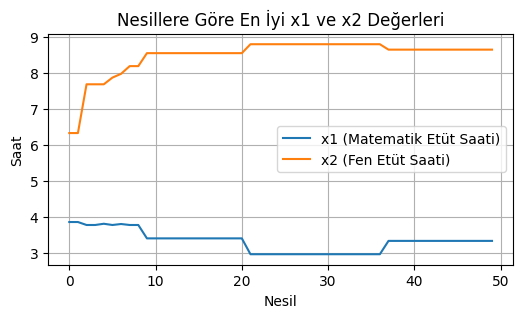

In [52]:
# x1 ve x2 aynı grafikte
plt.figure(figsize=(6, 3))
plt.plot(en_iyi_x1_list, label="x1 (Matematik Etüt Saati)")
plt.plot(en_iyi_x2_list, label="x2 (Fen Etüt Saati)")
plt.title("Nesillere Göre En İyi x1 ve x2 Değerleri")
plt.xlabel("Nesil")
plt.ylabel("Saat")
plt.legend()
plt.grid(True)
plt.show()

## **12) En İyi Fitness Değerinin Nesillere Göre Görselleştirilmesi**

Bu hücrede, genetik algoritmanın her nesilde ulaştığı en iyi fitness değerinin zaman içindeki değişimi grafiksel olarak gösterilmektedir. Fitness grafiği, algoritmanın optimizasyon sürecinde ne ölçüde iyileşme sağladığını ve çözüm kalitesinin nesiller boyunca nasıl geliştiğini açık biçimde ortaya koyar.

Grafikte nesil numarası yatay eksende, en iyi fitness değeri ise düşey eksende yer alır. Nokta işaretleri kullanılması, özellikle ardışık nesiller arasındaki küçük iyileşmelerin veya duraksamaların daha net gözlemlenmesine yardımcı olur. Eğrinin belirli bir noktadan sonra yataylaşması, algoritmanın kararlı bir çözüme yakınsadığını gösterir.


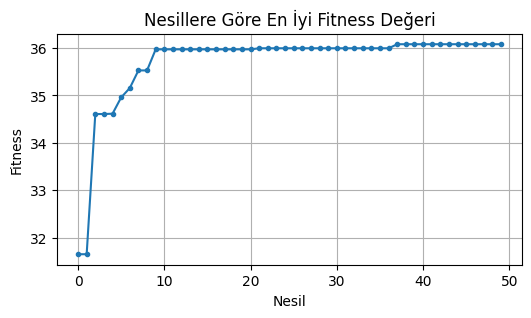

In [53]:
# Fitness grafiği
plt.figure(figsize=(6, 3))
plt.plot(en_iyi_fitness_list, marker="o", markersize=3)
plt.title("Nesillere Göre En İyi Fitness Değeri")
plt.xlabel("Nesil")
plt.ylabel("Fitness")
plt.grid(True)
plt.show()

# **YORUM**
Bu çalışmada, genetik algoritma kullanılarak öğrencinin matematik (x₁) ve fen
(x₂) etüt sürelerinin optimize edilmesi amaçlanmıştır. Amaç fonksiyonu, çalışma süresinin başarı üzerindeki olumlu etkisini ve aşırı çalışmanın verim düşürücü etkisini birlikte modellemektedir.

Başlangıç popülasyonu, x₁ ve x₂ değişkenleri için belirlenen aralıklar içinde rastgele oluşturulmuştur. Fitness değeri hesaplanırken kısıt ihlalleri ceza  yöntemi ile ele alınmış, böylece kısıtlara uymayan bireylerin seçilme olasılığı azaltılmıştır. Seçim aşamasında rulet tekerleği yöntemi kullanılmış, tek noktalı çaprazlama ve mutasyon işlemleri ile yeni bireyler üretilmiştir. Ayrıca elitizm yöntemi ile her neslin en iyi bireyi korunmuştur.

# **SONUÇ**
Genetik algoritma sonucunda, başarı skorunu maksimize eden uygun etüt süreleri elde edilmiştir. Nesiller ilerledikçe en iyi fitness değerinin arttığı ve belirli bir noktadan sonra kararlı hale geldiği gözlemlenmiştir.

En iyi çözümde matematik etüt süresi (x₁), fen etüt süresi ise (x₂) olarak bulunmaktadır. Bu çözüm, x₁ + x₂ ≤ 12 ve x₂ ≥ 2 kısıtlarını sağlamaktadır. Sonuç olarak, genetik algoritma yöntemi kısıtlı optimizasyon problemlerinde etkili ve uygulanabilir bir çözüm yaklaşımı sunmaktadır.